# Avaliação Final do Modelo — Milho

Este notebook consolida a **avaliação final** do melhor modelo de classificação de doenças do milho e cobre o fluxo completo: preparação do ambiente, carregamento de dados e modelo, cálculo de métricas, geração da matriz de confusão, logging no MLflow e validação/publicação da versão `pyfunc` para consumo em API.

> Objetivo principal: produzir uma avaliação reproduzível, auditável e pronta para operação em produção.


In [0]:
%load_ext autoreload
%autoreload 2

In [0]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import tempfile
import base64
from datetime import datetime
from IPython.display import HTML, display

import mlflow
from mlflow.models.signature import infer_signature

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch

from src.dataset.milho_dataset import get_dataloaders_milho
from src.evaluate import evaluate_model

In [0]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "/Volumes/workspace/agro-diasease/data/dados_divididos"

best_run_id = "39efe20dccaf4baf9c33e4e128c93067"

## 2. Preparação do conjunto de teste

Aqui carregamos o `DataLoader` de teste com `get_dataloaders_milho(...)` e recuperamos a lista de classes.

- `test_loader` será usado pela função `evaluate_model`.
- `classes` é usada para interpretar rótulos numéricos e nomear eixos da matriz de confusão.
- O `print` esperado exibe algo como `Classes: [...]`, confirmando que o mapeamento de classes foi carregado corretamente.


In [0]:
_, _, test_loader, classes = get_dataloaders_milho(data_dir=data_dir)

numero_classes = len(classes)

print("Classes:", classes)

Classes: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


## 3. Carregamento do melhor modelo

Com o `best_run_id` selecionado no notebook de treinamento, carregamos o artefato salvo no MLflow usando URI no formato `runs:/<run_id>/model`.

Após o carregamento:
- o modelo é movido para o dispositivo (`CPU`/`CUDA`),
- definido em modo de inferência com `eval()`,
- e o output textual confirma que o objeto foi carregado com sucesso.


In [0]:
model_uri = f"runs:/{best_run_id}/model"
model = mlflow.pytorch.load_model(model_uri)

model.to(device)
model.eval()

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


## 4. Execução da avaliação

Executamos `evaluate_model(...)` no conjunto de teste para obter os principais resultados:

- `accuracy` (acurácia global),
- `classification_report` (precision, recall, f1-score por classe),
- `confusion_matrix` (contagens de acertos/erros por classe).

Os `prints` desta célula servem como checagem rápida de qualidade antes da etapa de visualização e logging.


In [0]:
result = evaluate_model(
    model,
    test_loader,
    device,
    class_names=classes
)

print("Test Accuracy:", result["accuracy"])
print(result["classification_report"])

Test Accuracy: 0.9173290937996821
                precision    recall  f1-score   support

        Blight       0.82      0.92      0.87       172
   Common_Rust       0.98      0.93      0.96       196
Gray_Leaf_Spot       0.80      0.71      0.75        86
       Healthy       1.00      1.00      1.00       175

      accuracy                           0.92       629
     macro avg       0.90      0.89      0.89       629
  weighted avg       0.92      0.92      0.92       629



## 5. Visualização da matriz de confusão

A matriz de confusão ajuda a identificar **quais classes são mais confundidas** pelo modelo.

Nesta célula:
- usamos `seaborn.heatmap` para visualização,
- rotulamos eixos como **Predito** e **Real**,
- salvamos a figura em `figures/confusion_matrix_test.png` para posterior rastreabilidade no MLflow,
- e exibimos a imagem inline no notebook.


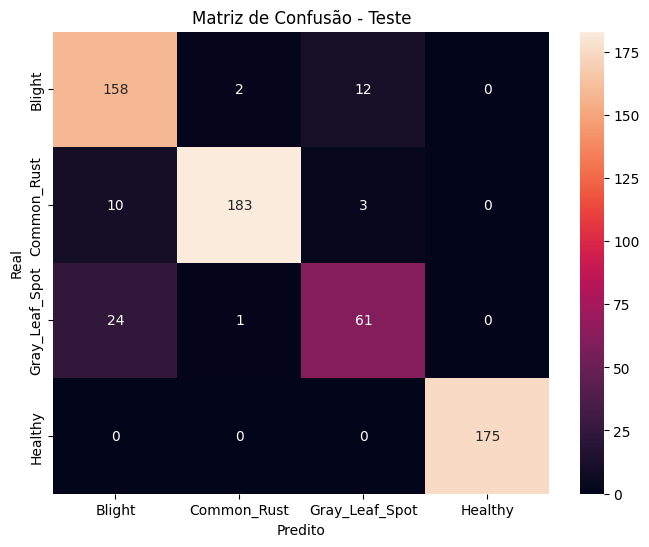

In [0]:
cm = result["confusion_matrix"]

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Teste")

plt.savefig("figures/confusion_matrix_test.png")
plt.show()

## 6. Registro dos resultados no MLflow

Nesta etapa registramos a avaliação como um novo run no experimento `/Shared/Milho_Doencas`.

Itens logados:
- parâmetro `evaluated_run_id` (qual run foi avaliado),
- métrica `test_accuracy`,
- artefato da matriz de confusão (`.png`),
- artefato de relatório textual (`classification_report.txt`).

Com isso, a avaliação fica versionada e comparável dentro do histórico do MLflow.


In [0]:
mlflow.set_experiment("/Shared/Milho_Doencas")

with mlflow.start_run(run_name="evaluation_best_model"):

    mlflow.log_param("evaluated_run_id", best_run_id)

    mlflow.log_metric("test_accuracy", result["accuracy"])

    mlflow.log_artifact("figures/confusion_matrix_test.png")

    with open("classification_report.txt", "w") as f:
        f.write(result["classification_report"])

    mlflow.log_artifact("classification_report.txt")

    print("Avaliação logada no MLflow!")

Avaliação logada no MLflow!


## 7. Validação do modelo `pyfunc` carregado do MLflow

Aqui fazemos um teste funcional de ponta a ponta do modelo empacotado como `mlflow.pyfunc`:

- carregamos o modelo por `run_id` específico,
- extraímos uma amostra real do dataset de teste (`image, label`),
- chamamos `predict(...)` com batch unitário,
- comparamos a predição com o rótulo real e exibimos a confiança.

A saída esperada (mensagem de sucesso + predição/confiança/label real) confirma que o artefato está servível para integração.


In [0]:
pyfunc_run_id = "7e4caf958d4a4b5d8a3a7177989914c2"
test_model_uri = f"runs:/{pyfunc_run_id}/model"

loaded_pyfunc_model = mlflow.pyfunc.load_model(test_model_uri)

data_dir = "/Volumes/workspace/agro-diasease/data/dados_divididos"
_, _, test_loader, classes = get_dataloaders_milho(data_dir=data_dir)

image, label = test_loader.dataset[1]

prediction = loaded_pyfunc_model.predict(
    image.unsqueeze(0).numpy()
)
label_real = classes[label]

print("\n✅ Teste de carregamento bem-sucedido!")
print(f"Predição: {prediction[0]['prediction']}")
print(f"Confiança: {prediction[0]['confidence']:.4f}")
print(f"Label real: {label_real}")


✅ Teste de carregamento bem-sucedido!
Predição: Blight
Confiança: 0.9684
Label real: Blight


## 8. Registro do modelo no Model Registry e criação de alias

Após validar a inferência, registramos o modelo no catálogo com nome estável (`modelo_milho_doencas_pyfunc`).

Nesta célula:
- criamos uma nova versão no Registry,
- definimos o alias `@production` para essa versão,
- e imprimimos o URI recomendado para uso em aplicações (`models:/...@production`).

Esse passo desacopla a API de `run_id` fixo e facilita promoção de versões.


In [0]:
model_name = "modelo_milho_doencas_pyfunc"
model_uri = f"runs:/{pyfunc_run_id}/model"

print(f"Registrando modelo no Unity Catalog: {model_name}")

model_version = mlflow.register_model(
    model_uri=model_uri,
    name=model_name
)

print(f"\n✅ Modelo registrado como versão {model_version.version}")

client = mlflow.tracking.MlflowClient()
client.set_registered_model_alias(
    name=model_name,
    alias="production",
    version=model_version.version
)

print(f"✅ Alias '@production' definido para versão {model_version.version}")
print(f"\n📌 Para usar na API:")
print(f"   MODEL_URI = 'models:/{model_name}@production'")
print(f"   model = mlflow.pyfunc.load_model(MODEL_URI)")

Registrando modelo no Unity Catalog: modelo_milho_doencas_pyfunc


Registered model 'modelo_milho_doencas_pyfunc' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]


✅ Modelo registrado como versão 2


Created version '2' of model 'workspace.default.modelo_milho_doencas_pyfunc'.


✅ Alias '@production' definido para versão 2

📌 Para usar na API:
   MODEL_URI = 'models:/modelo_milho_doencas_pyfunc@production'
   model = mlflow.pyfunc.load_model(MODEL_URI)


## 9. Exportação do modelo de produção para arquivo ZIP

Por fim, baixamos o modelo publicado via URI com alias de produção e geramos um pacote `.zip` com timestamp UTC.

Fluxo executado:
- download dos artefatos para diretório temporário,
- compactação com `shutil.make_archive`,
- conversão do ZIP para Base64,
- renderização de link HTML para download direto no notebook.

Resultado: um artefato portátil do modelo pronto para compartilhamento, backup ou deploy externo.


In [0]:
model_uri = "models:/workspace.default.modelo_milho_doencas_pyfunc@production" 


tmp_dir = tempfile.mkdtemp(prefix="mlflow_model_")
model_dir = mlflow.artifacts.download_artifacts(
    artifact_uri=model_uri,
    dst_path=tmp_dir
)

ts = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
zip_base = os.path.join(tmp_dir, f"modelo_pyfunc_{ts}")
zip_path = shutil.make_archive(zip_base, "zip", model_dir)

print("Modelo baixado em:", model_dir)
print("ZIP criado em:", zip_path)

with open(zip_path, "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")

filename = os.path.basename(zip_path)
html = f'''
<a download="{filename}" href="data:application/zip;base64,{b64}" target="_blank">
  ⬇️ Clique aqui para baixar {filename}
</a>
'''
display(HTML(html))

Modelo baixado em: /tmp/mlflow_model_i6_2sj0a/
ZIP criado em: /tmp/mlflow_model_i6_2sj0a/modelo_pyfunc_20260326_191250.zip


/home/spark-842d162a-8ea5-47c5-9912-db/.ipykernel/15272/command-8142709861149510-2522637536:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow().strftime("%Y%m%d_%H%M%S")
